This is a sample code of implementation of PINNs on Cavity problem

In [ ]:
# Import
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as op

from scipy.interpolate import griddata

In [ ]:
# Create the NN
class CavNN(nn.Module):

    ''' Inputs x,y,t and outputs u, v, p'''
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=3, out_features=30),
            nn.Tanh(),
            nn.Linear(in_features=30, out_features=60),
            nn.Tanh(),
            nn.Linear(in_features=60, out_features=60),
            nn.Tanh(),
            nn.Linear(in_features=60, out_features=60),
            nn.Tanh(),
            nn.Linear(in_features=60, out_features=60),
            nn.Tanh(),
            nn.Linear(in_features=60, out_features=30),
            nn.Tanh(),
            nn.Linear(in_features=30, out_features=30),
            nn.Tanh(),
            nn.Linear(in_features=30, out_features=3)
        )

    def forward(self, X):
        out = self.net(X)
        return out

In [ ]:
# Per-train and training settings
class Net:

    def __init__(self, u0=1, rho=1, nu=0.1):

        # GPU
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"{device} is available!")

        # NN, Initial u, Density, Viscosity
        self.model = CavNN().to(device)
        self.u0 = u0
        self.rho = rho
        self.nu = nu

        # Computation domain
        self.x_step = 0.1
        self.y_step = 0.1
        self.t_step = 0.1
        x = torch.arange(-1, 1+self.x_step, self.x_step)
        y = torch.arange(-1, 1+self.y_step, self.y_step)
        t = torch.arange( 0, 1+self.t_step, self.t_step)

        self.X = torch.stack(torch.meshgrid(x, y, t, indexing="xy")).view(3, -1).T.requires_grad_()

        # BCs
        # Left Wall (x = -1)
        boundary_mask_left = self.X[:, 0] == -1                     # Boolean mask for x = -1
        bl = self.X[boundary_mask_left]
        bl = bl[(bl[:, 1] != -1) & (bl[:, 1] != 1)]                 # Remove those belong to bd and bu (y = -1,1)                             
        y_bl = torch.zeros(2*len(bl)).view(-1, 2)                   # No-slip condition: (u, v) = (0, 0)

        # Right Wall (x = 1)
        boundary_mask_right = self.X[:, 0] == 1                     # Boolean mask for x = 1
        br = self.X[boundary_mask_right]
        br = br[(br[:, 1] != -1) & (br[:, 1] != 1)]                 # Remove those belong to bd and bu (y = -1,1)
        y_br = torch.zeros(2*len(br)).view(-1, 2)                   # No-slip condition: (u, v) = (0, 0)

        # Bottom Wall (y = -1)
        boundary_mask_down = self.X[:, 1] == -1                     # Boolean mask for y = -1
        bd = self.X[boundary_mask_down]
        y_bd = torch.zeros(2*len(bd)).view(-1, 2)                   # No-slip condition: (u, v) = (0, 0)  

        # Top Wall (y = 1)
        boundary_mask_up = self.X[:, 1] == 1                        # Boolean mask for y = 1
        bu = self.X[boundary_mask_up]  
        u_bu = torch.ones(len(bu), 1) * self.u0                     # Lid moves with velocity u = u0, v = 0
        v_bu = torch.zeros(len(bu), 1)
        y_bu = torch.cat([u_bu, v_bu], dim=1)

        # ICs
        initial_mask = self.X[:, 2] == 0
        ic = self.X[initial_mask]
        y_ic = torch.zeros(2*len(ic)).view(-1, 2)                   # Initial: (u, v) = (0, 0)

        # Concatenate
        self.x_train = torch.cat([bl, br, bd, bu, ic])
        self.y_train = torch.cat([y_bl, y_br, y_bd, y_bu, y_ic])
        self.y_train = self.y_train.view(-1, 2)                     # Ensures correct (N, 2) shape

        # Move to device
        self.X = self.X.to(device)
        self.x_train = self.x_train.to(device)
        self.y_train = self.y_train.to(device)

        # Optimizers
        # Adam
        self.adam = op.Adam(self.model.parameters())
        # Limited-memory Broyden-Fletcher-Goldfarb-Shanno (L-BFGS)
        self.optimizer = op.LBFGS(
            self.model.parameters(),
            lr = 1.0,
            max_iter = 10000,
            max_eval = 10000,
            history_size = 50,
            tolerance_grad = 1e-07,
            tolerance_change = 1.0 * np.finfo(float).eps,
            line_search_fn = "strong_wolfe"
        )

        # Loss function
        self.loss = nn.MSELoss()
        self.iter = 1
        self.loss_history = []

    # Loss and backprop
    def loss_fn(self):
        self.adam.zero_grad()
        self.optimizer.zero_grad()

        # Data loss
        y_pred = self.model(self.x_train)
        loss_train = self.loss(y_pred[:, [0,1]], self.y_train)

        # PDE loss
        u_v_p = self.model(self.X)
        u = u_v_p[:, 0]                                               # Extract horizontal velocity (u)
        v = u_v_p[:, 1]                                               # Extract vertical velocity (v)
        p = u_v_p[:, 2]                                               # Extract pressure (p)

        # Compute first-order derivatives
        du_dX = torch.autograd.grad(
            u, self.X,
            grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        
        dv_dX = torch.autograd.grad(
            v, self.X,
            grad_outputs=torch.ones_like(v),
            create_graph=True, retain_graph=True
        )[0]

        dp_dX = torch.autograd.grad(
            p, self.X,
            grad_outputs=torch.ones_like(p),
            create_graph=True, retain_graph=True
        )[0]

        du_dt = du_dX[:, 2]  # ∂u/∂t
        du_dx = du_dX[:, 0]  # ∂u/∂x
        du_dy = du_dX[:, 1]  # ∂u/∂y

        dv_dt = dv_dX[:, 2]  # ∂v/∂t
        dv_dx = dv_dX[:, 0]  # ∂v/∂x
        dv_dy = dv_dX[:, 1]  # ∂v/∂y

        dp_dx = dp_dX[:, 0]  # ∂p/∂x
        dp_dy = dp_dX[:, 1]  # ∂p/∂y

        # Compute second-order derivatives
        du_dXX = torch.autograd.grad(
            du_dX, self.X,
            grad_outputs=torch.ones_like(du_dX),
            create_graph=True, retain_graph=True
        )[0]

        dv_dXX = torch.autograd.grad(
            dv_dX, self.X,
            grad_outputs=torch.ones_like(dv_dX),
            create_graph=True, retain_graph=True
        )[0]

        du_dxx = du_dXX[:, 0]  # ∂²u/∂x²
        du_dyy = du_dXX[:, 1]  # ∂²u/∂y²

        dv_dxx = dv_dXX[:, 0]  # ∂²v/∂x²
        dv_dyy = dv_dXX[:, 1]  # ∂²v/∂y²

        # PDE residuals
        momentum_x = du_dt + u * du_dx + v * du_dy + dp_dx/self.rho - self.nu * (du_dxx + du_dyy)
        momentum_y = dv_dt + u * dv_dx + v * dv_dy + dp_dy/self.rho - self.nu * (dv_dxx + dv_dyy)
        continuity = du_dx + dv_dy                                  # Incompressible continuity equation

        # Compute PDE loss
        loss_pde_x = self.loss(momentum_x, torch.zeros_like(momentum_x))
        loss_pde_y = self.loss(momentum_y, torch.zeros_like(momentum_y))
        loss_continuity = self.loss(continuity, torch.zeros_like(continuity))

        # Total PDE loss
        loss_pde = loss_pde_x + loss_pde_y + loss_continuity

        # Total loss
        total_loss = loss_train + loss_pde

        # Backprop
        total_loss.backward(retain_graph=True)

        # Log the loss
        self.loss_history.append(total_loss.item())
        
        # Track training
        if self.iter % 100 == 0:
            print(f"Iteration:{self.iter}, Total loss: {total_loss.item()}, PDE loss: {loss_pde}, Data loss: {loss_train}")
        self.iter += 1

        return total_loss
    
    # Train mode
    def train(self):
        self.model.train()                                          # Sets model to training mode
        for _ in range(2000):
            self.adam.step(self.loss_fn)
        self.optimizer.step(self.loss_fn)

    # Not-tracking grads
    def eval_(self):
        self.model.eval()                                           # Switch model to evaluation mode



In [4]:
# Train the model
net = Net(u0=2, rho=1, nu=0.1)
net.train()

cuda is available!
Iteration:100, Total loss: 0.07474474608898163, PDE loss: 0.007924419827759266, Data loss: 0.06682032346725464
Iteration:200, Total loss: 0.052642807364463806, PDE loss: 0.0020655279513448477, Data loss: 0.050577279180288315
Iteration:300, Total loss: 0.04701344296336174, PDE loss: 0.0018285512924194336, Data loss: 0.045184891670942307
Iteration:400, Total loss: 0.044500622898340225, PDE loss: 0.0022146841511130333, Data loss: 0.04228593781590462
Iteration:500, Total loss: 0.04198141768574715, PDE loss: 0.0013494347222149372, Data loss: 0.0406319834291935
Iteration:600, Total loss: 0.04135162755846977, PDE loss: 0.0017675671260803938, Data loss: 0.03958405926823616
Iteration:700, Total loss: 0.041801221668720245, PDE loss: 0.0025752224028110504, Data loss: 0.039225999265909195
Iteration:800, Total loss: 0.041317570954561234, PDE loss: 0.0036527805496007204, Data loss: 0.03766478970646858
Iteration:900, Total loss: 0.03800847381353378, PDE loss: 0.0011867263820022345,

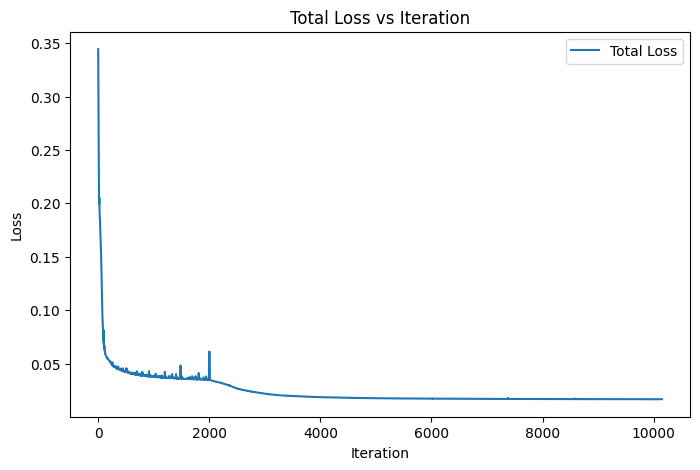

In [5]:
# Plot the loss history
plt.figure(figsize=(8, 5))
plt.plot(net.loss_history, label="Total Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Total Loss vs Iteration")
plt.legend()
plt.show()

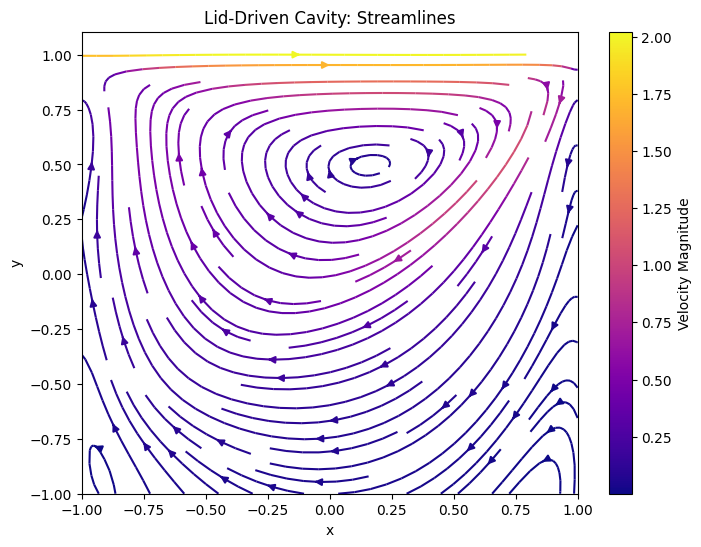

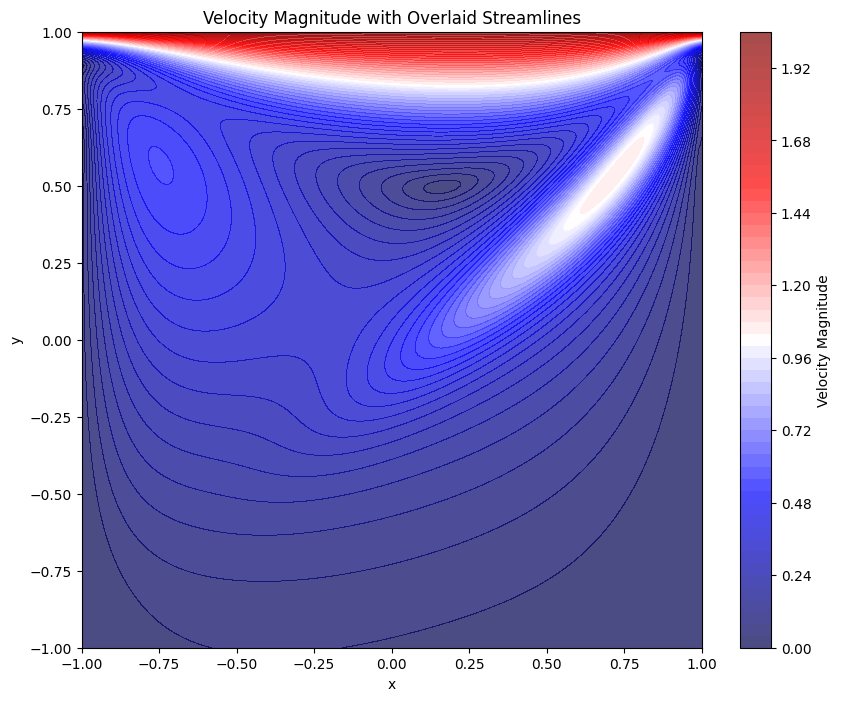

In [ ]:
# Make a prediction and test
x_step = 0.01
y_step = 0.01
t_step = 0.1
x = torch.arange(-1, 1+x_step, x_step)
y = torch.arange(-1, 1+y_step, y_step)
t = torch.arange( 0, 1+t_step, t_step)

X = torch.stack(torch.meshgrid(x, y, t, indexing="xy")).view(3, -1).T
X = X.to(net.X.device)

model = net.model
model.eval()

# Get predicted velocities
with torch.no_grad():  # Disable gradient tracking for inference
    u_v_pred = model(X)  # Predictions for all points
    u_pred = u_v_pred[:, 0].cpu().unsqueeze(1).numpy()  # Convert u to NumPy for plotting
    v_pred = u_v_pred[:, 1].cpu().numpy()  # Convert v to NumPy for plotting

# Extract spatial coordinates
X_np = X.cpu().detach().numpy()
x_vals = X_np[:, 0]
y_vals = X_np[:, 1]

# Extract data for a single time step (e.g., t = 1)
time_index = (X_np[:, 2] == 1)  # Choose the time step
x_vals_t1 = x_vals[time_index]
y_vals_t1 = y_vals[time_index]
u_pred_t1 = u_pred[time_index]
v_pred_t1 = v_pred[time_index]

# Create grid for contour plotting
xi = x_vals_t1.reshape(len(x), len(y))
yi = y_vals_t1.reshape(len(x), len(y))
ui = u_pred_t1.reshape(len(x), len(y))
vi = v_pred_t1.reshape(len(x), len(y))

# Velocity
velocity_magnitude = np.sqrt(ui**2 + vi**2)

# Streamlines
plt.figure(figsize=(8,6))
plt.streamplot(xi, yi, ui, vi, color=np.sqrt(ui**2 + vi**2), cmap="plasma")
plt.title("Lid-Driven Cavity: Streamlines")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label="Velocity Magnitude")
plt.show()

# Interpolate velocity magnitude onto the finer grid
velocity_magnitude_fine = griddata(
    (xi.flatten(), yi.flatten()),
    velocity_magnitude.flatten(),
    (xi, yi),
    method='cubic'  # 'linear' or 'nearest' are alternatives
)

# Create the contour plot and streamlines overlaid
plt.figure(figsize=(10, 8))
contour = plt.contourf(xi, yi, velocity_magnitude_fine, levels=50, cmap='seismic', alpha=0.7)
plt.colorbar(contour, label='Velocity Magnitude')
plt.streamplot(xi, yi, ui, vi, color='black', density=2, linewidth=1, cmap="plasma")
plt.title("Velocity Magnitude with Overlaid Streamlines")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# # Contour 2
# sns.set_style("white")
# plt.figure(figsize=(5,3), dpi=3000)
# sns.heatmap(velocity_magnitude, cmap="jet")
# plt.gca().invert_yaxis()  # Ensures correct orientation
# plt.show()

# # Contour 3
# plt.figure(figsize=(8, 6))
# contour = plt.contourf(xi, yi, velocity_magnitude, levels=50, cmap='seismic')
# plt.colorbar(contour, label='Velocity Magnitude')
# plt.title("Velocity Magnitude Contour")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.show()